In [1]:
import os
import pandas as pd
from PIL import Image
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import timm
#models = timm.list_models(pretrained=True)
#[name for name in models if "efficientnetv2" in name]

In [2]:
METADATA_PATH = "/kaggle/input/skin-cancer-dataset/HAM10000_metadata.csv"
IMAGE_DIR = "/kaggle/input/skin-cancer-dataset/Skin Cancer/Skin Cancer"
BATCH_SIZE = 32  # B3 is bigger, reduce batch if GPU memory issues
EPOCHS = 100
NUM_WORKERS = 2
LR = 1e-4
PATIENCE = 15  # early stopping patience, scrapped cuz testing without it
INPUT_SIZE = 224  # for B3 (b0 is 224 x 224)

In [3]:
df = pd.read_csv(METADATA_PATH)
df['image_path'] = df['image_id'].apply(lambda x: os.path.join(IMAGE_DIR, f"{x}.jpg"))
df = df[df['image_path'].apply(os.path.exists)]
label_encoder = LabelEncoder()
df['label'] = label_encoder.fit_transform(df['dx'])
num_classes = len(label_encoder.classes_)

train_df, val_df = train_test_split(df, test_size=0.2, stratify=df['label'], random_state=42)

In [4]:
class SkinCancerDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = self.df.loc[idx, 'image_path']
        label = self.df.loc[idx, 'label']
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, label

In [5]:
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(INPUT_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406], [0.229,0.224,0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((INPUT_SIZE, INPUT_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406], [0.229,0.224,0.225])
])

train_loader = DataLoader(SkinCancerDataset(train_df, transform=train_transform),
                          batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
val_loader = DataLoader(SkinCancerDataset(val_df, transform=val_transform),
                        batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

In [6]:
class EarlyStopping:
    def __init__(self, patience=10, verbose=True, delta=0.0):
        self.patience = patience
        self.verbose = verbose
        self.delta = delta
        self.best_loss = float('inf')
        self.counter = 0
        self.early_stop = False

    def __call__(self, val_loss):
        if val_loss < self.best_loss - self.delta:
            self.best_loss = val_loss
            self.counter = 0
        else:
            self.counter += 1
            if self.verbose:
                print(f"EarlyStopping counter: {self.counter} out of {self.patience}")
            if self.counter >= self.patience:
                self.early_stop = True

In [7]:
device = "cuda" if torch.cuda.is_available() else "cpu"

# model loading
model = timm.create_model("tf_efficientnetv2_b3.in21k_ft_in1k", pretrained=False, num_classes=num_classes) #set to true if not using your own trained model
model.to(device)
model.load_state_dict(torch.load("/kaggle/input/latest/pytorch/default/1/best_model (2).pt", map_location=device))

# loss calc (short for calculatoir)
class_counts = df['label'].value_counts().sort_index().values
class_weights = torch.tensor(1.0 / class_counts, dtype=torch.float).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

In [8]:
early_stopper = EarlyStopping(patience=PATIENCE)
log_file = "/kaggle/working/training_log.csv"


#writes the accuracy and stuff in the output csv file
import csv
with open(log_file, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["epoch", "train_loss", "val_loss", "val_acc"])

best_val_loss = float('inf')

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0.0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * images.size(0)

    avg_train_loss = total_loss / len(train_loader.dataset)

    # Validation
    model.eval()
    val_loss = 0.0
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * images.size(0)

            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    avg_val_loss = val_loss / len(val_loader.dataset)
    val_acc = 100 * correct / total

    print(f"Epoch [{epoch+1}/{EPOCHS}], Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}, Val Acc: {val_acc:.2f}%")

    # Save best model
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), "/kaggle/working/best_model.pt")
        print("Saved new best model (Val Loss went down).")

    # Log metrics
    with open(log_file, "a", newline="") as f:
        writer = csv.writer(f)
        writer.writerow([epoch+1, avg_train_loss, avg_val_loss, val_acc])

    # Early stopping, commented to test without it
    early_stopper(avg_val_loss)
    if early_stopper.early_stop:
        print("Early stopping triggered.")
        break

    scheduler.step()


Epoch [1/100], Train Loss: 0.2698, Val Loss: 0.5916, Val Acc: 86.82%
Saved new best model (Val Loss went down).
Epoch [2/100], Train Loss: 0.2396, Val Loss: 0.6316, Val Acc: 88.02%
EarlyStopping counter: 1 out of 15
Epoch [3/100], Train Loss: 0.2295, Val Loss: 0.5958, Val Acc: 88.27%
EarlyStopping counter: 2 out of 15
Epoch [4/100], Train Loss: 0.2251, Val Loss: 0.6470, Val Acc: 88.12%
EarlyStopping counter: 3 out of 15
Epoch [5/100], Train Loss: 0.2393, Val Loss: 0.7453, Val Acc: 87.22%
EarlyStopping counter: 4 out of 15
Epoch [6/100], Train Loss: 0.2118, Val Loss: 0.6603, Val Acc: 88.87%
EarlyStopping counter: 5 out of 15
Epoch [7/100], Train Loss: 0.2364, Val Loss: 0.5256, Val Acc: 88.02%
Saved new best model (Val Loss went down).
Epoch [8/100], Train Loss: 0.2037, Val Loss: 0.5837, Val Acc: 88.67%
EarlyStopping counter: 1 out of 15
Epoch [9/100], Train Loss: 0.1804, Val Loss: 0.6603, Val Acc: 87.97%
EarlyStopping counter: 2 out of 15
Epoch [10/100], Train Loss: 0.2011, Val Loss: 0.

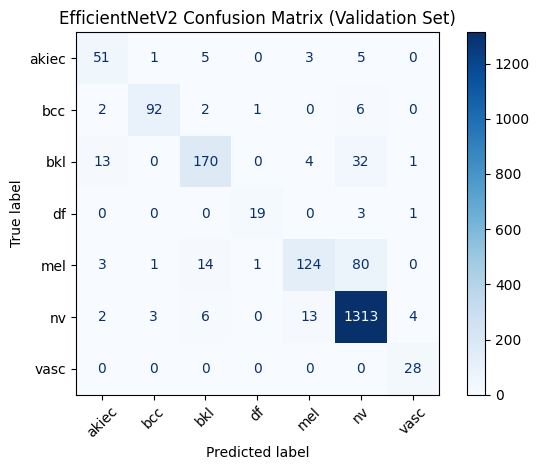


Classification Report:

              precision    recall  f1-score   support

       akiec     0.7183    0.7846    0.7500        65
         bcc     0.9485    0.8932    0.9200       103
         bkl     0.8629    0.7727    0.8153       220
          df     0.9048    0.8261    0.8636        23
         mel     0.8611    0.5561    0.6757       223
          nv     0.9124    0.9791    0.9446      1341
        vasc     0.8235    1.0000    0.9032        28

    accuracy                         0.8972      2003
   macro avg     0.8616    0.8303    0.8389      2003
weighted avg     0.8955    0.8972    0.8914      2003



In [9]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt
import numpy as np

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

cm = confusion_matrix(all_labels, all_preds)
class_names = list(label_encoder.classes_)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap='Blues', values_format='d')
plt.title("EfficientNetV2 Confusion Matrix (Validation Set)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("confusion_matrix.png")
plt.show()

report = classification_report(all_labels, all_preds, target_names=class_names, digits=4)
print("\nClassification Report:\n")
print(report)

with open("classification_report.txt", "w") as f:
    f.write(report)